In [1]:
import pandas as pd
import numpy as np

In [2]:
import os, sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
from src.models.quantile_regression import QuantileRegressionV1
from src.optimizers.RMSProp import RMSPropOtimizer

In [49]:
data = pd.read_csv("../../dataset/foodDeli_processed/train_processed.csv")

In [5]:
data.head()

,Delivery_person_Age,Delivery_person_Ratings,Distance_km,Preparation_Time,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,Road_traffic_density_Jam,...,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Vehicle_condition_1,Vehicle_condition_2,Festival_Yes,City_Semi-Urban,City_Urban,Time_taken
0,1.283313,0.846622,-1.202059,1.228728,0,0,0,1,0,0,...,0,1,1,0,0,1,0,0,1,24
1,0.762428,-0.418372,2.263776,-1.218497,0,0,1,0,0,1,...,0,1,0,1,0,1,0,0,0,33
2,-1.147486,-0.734620,-1.118905,1.228728,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,26
3,1.456942,0.214125,-0.035496,0.005115,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,21
4,0.415171,-0.102123,-0.613995,1.228728,0,0,0,0,0,0,...,0,1,0,1,1,0,0,0,0,30


In [51]:
np.random.seed(42)
shuffled_indices = np.random.permutation(len(data))

train_size = int(len(data) * 0.8)

data_train = data.iloc[shuffled_indices[:train_size]]
data_test = data.iloc[shuffled_indices[train_size:]]

In [54]:
data_train.shape

(30043, 23)

In [55]:
data_test.shape

(7511, 23)

In [65]:
X_train = np.array(data_train.drop(columns="Time_taken"))
y_train = np.array(data_train["Time_taken"])
X_test = np.array(data_test.drop(columns="Time_taken"))
y_test = np.array(data_test["Time_taken"])

In [66]:
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

In [164]:
rmsprop = RMSPropOtimizer(lr=0.1)

In [165]:
model = QuantileRegressionV1(optimizer=rmsprop)

In [166]:
model.fit(X_train, y_train, epochs=10000)

Epoch 0/10000, Loss: 23.8476
Epoch 100/10000, Loss: 1.8885
Epoch 200/10000, Loss: 1.3772
Epoch 300/10000, Loss: 1.2280
Epoch 400/10000, Loss: 1.1368
Epoch 500/10000, Loss: 1.1022
Epoch 600/10000, Loss: 1.0930
Epoch 700/10000, Loss: 1.0905
Epoch 800/10000, Loss: 1.0902
Epoch 900/10000, Loss: 1.0901
Epoch 1000/10000, Loss: 1.0903
Epoch 1100/10000, Loss: 1.0902
Epoch 1200/10000, Loss: 1.0902
Epoch 1300/10000, Loss: 1.0900
Epoch 1400/10000, Loss: 1.0900
Epoch 1500/10000, Loss: 1.0901
Epoch 1600/10000, Loss: 1.0901
Epoch 1700/10000, Loss: 1.0904
Epoch 1800/10000, Loss: 1.0901
Epoch 1900/10000, Loss: 1.0904
Epoch 2000/10000, Loss: 1.0903
Epoch 2100/10000, Loss: 1.0902
Epoch 2200/10000, Loss: 1.0902
Epoch 2300/10000, Loss: 1.0901
Epoch 2400/10000, Loss: 1.0902
Epoch 2500/10000, Loss: 1.0901
Epoch 2600/10000, Loss: 1.0902
Epoch 2700/10000, Loss: 1.0902
Epoch 2800/10000, Loss: 1.0903
Epoch 2900/10000, Loss: 1.0902
Epoch 3000/10000, Loss: 1.0900
Epoch 3100/10000, Loss: 1.0901
Epoch 3200/10000, L

In [167]:
loss = model.loss

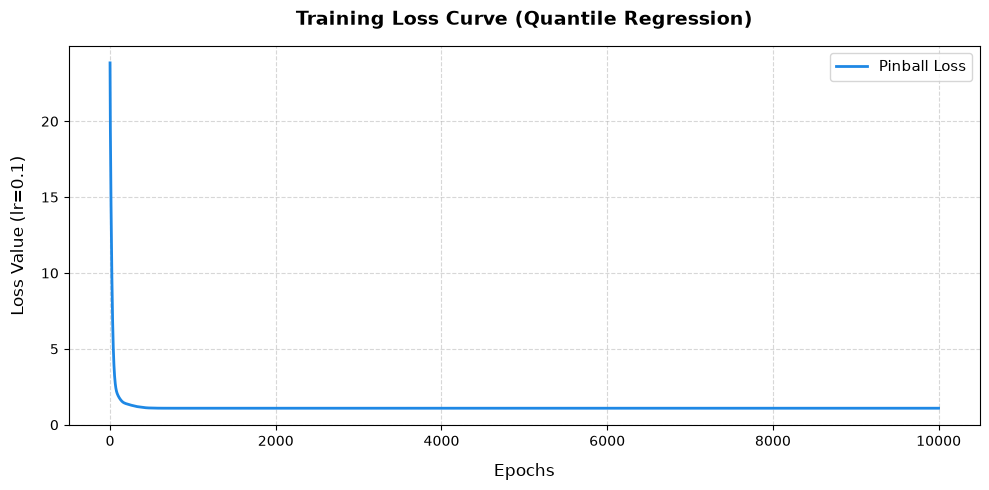

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(loss, label='Pinball Loss', color='#1E88E5', linewidth=2)

plt.title('Training Loss Curve (Quantile Regression)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12, labelpad=10)
plt.ylabel('Loss Value (lr=0.1)', fontsize=12, labelpad=10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

In [169]:
y_pred = model.predict(X_test)

test_pinball_loss = model.pinball_loss(y_test, y_pred)
test_mae = np.mean(np.abs(y_test - y_pred))
test_rmse = np.sqrt(np.mean((y_test - y_pred)**2))

coverage_ratio = np.mean(y_test <= y_pred)

print(f"Test Pinball Loss (tau=0.9): {test_pinball_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test Coverage Ratio: {coverage_ratio:.4f}")


Test Pinball Loss (tau=0.9): 1.0790
Test MAE: 8.7310
Test RMSE: 10.3086
Test Coverage Ratio: 0.9024


In [174]:

model.save_weights("../../results/weights/RMSProp/rms_weights.npy")

Saved.


In [170]:
np.save("../../results/weights/RMSProp/rms_loss_1.npy", np.array(loss))
print("Đã lưu biến loss thành công.")

Đã lưu biến loss thành công.


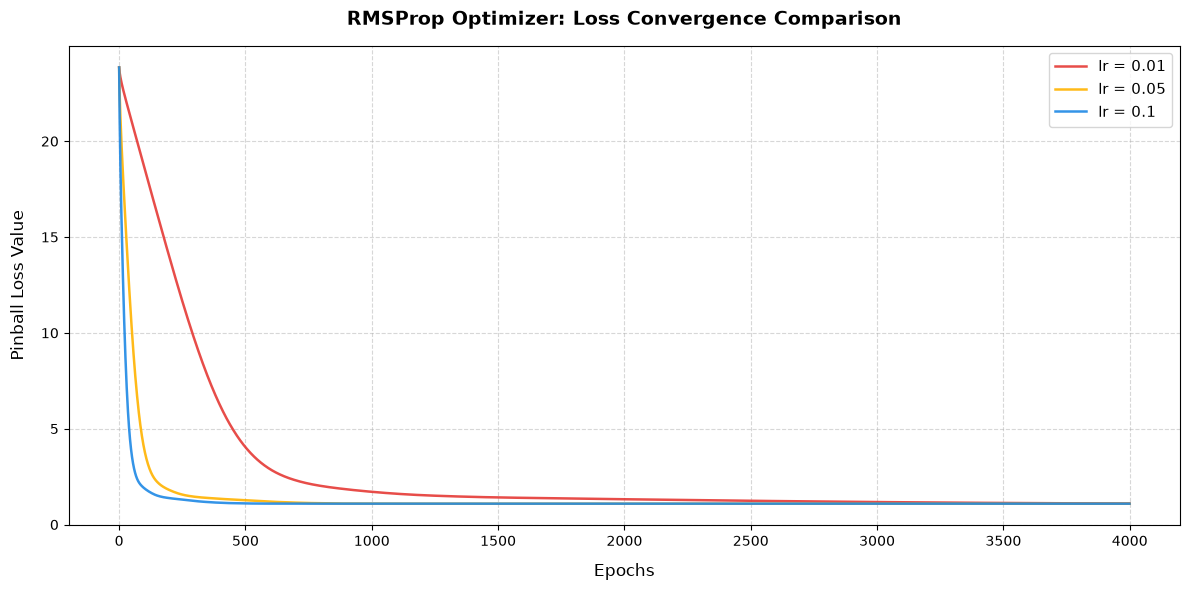

In [173]:
# 1. Đọc dữ liệu loss từ các tệp .npy
# (Đường dẫn tương đối tính từ thư mục notebooks/training/)
loss_01 = np.load("../../results/weights/RMSProp/rms_loss_01.npy")
loss_05 = np.load("../../results/weights/RMSProp/rms_loss_05.npy")
loss_1 = np.load("../../results/weights/RMSProp/rms_loss_1.npy")

# 2. Khởi tạo biểu đồ so sánh
plt.figure(figsize=(12, 6))

# Vẽ 3 đường với các màu sắc tương phản rõ nét
plt.plot(loss_01[:4000], label='lr = 0.01', color='#E53935', linewidth=1.8, alpha=0.9)
plt.plot(loss_05[:4000], label='lr = 0.05', color='#FFB300', linewidth=1.8, alpha=0.9)
plt.plot(loss_1[:4000], label='lr = 0.1', color='#1E88E5', linewidth=1.8, alpha=0.9)

# Cấu hình tiêu đề và các trục tọa độ
plt.title('RMSProp Optimizer: Loss Convergence Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12, labelpad=10)
plt.ylabel('Pinball Loss Value', fontsize=12, labelpad=10)

# Cấu hình lưới bổ trợ (grid) và ghi chú (legend)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

# Tối ưu hóa khoảng cách hiển thị
plt.tight_layout()

# Hiển thị đồ thị
plt.show()
